In [122]:
import pandas as pd
import numpy as np

In [123]:
# 1 Get wave 10 mortality data since wave 6 

#load wave 10 HCAP data  Healthy Cognitive Ageing Project https://www.elsa-project.ac.uk/hcap
fname = "C:/Users/dinab/Desktop/PostDoc/ELSA files/UKDA-5050-stata/stata/stata13_se/elsa_endoflife_hcap2_w10.dta"
df3 = pd.read_stata(fname)

# get ID, date of death and age at death
df3_short = df3[["idauniq", "eidatey", "eirage"]].copy()


In [124]:
# save this in a separate file w10_dod.csv 
df3_short.to_csv("C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/ELSA data/w10_dod.csv")

In [125]:
# 2 Merge with other data to add mortality up to the wave 8 in the main file 
fname0 = "C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/ELSA data/ELSA_short_df.csv"
df = pd.read_csv(fname0)

In [126]:
df.loc[df.idauniq == 162358, :]

,Unnamed: 0,idauniq,yob,yod,sex,eth,edu,wealth,date1,date2,...,psych_wave9,fallinj_wave1,fallinj_wave2,fallinj_wave3,fallinj_wave4,fallinj_wave5,fallinj_wave6,fallinj_wave7,fallinj_wave8,fallinj_wave9
16478,16478,162358,1937.0,NaN,0,0.0,2.0,3.0,2002.663,2004.967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
df_merged = df.merge(df3_short, on = "idauniq", how = "left")

In [137]:
df_merged['yod'] = df_merged['yod'].fillna(df_merged['eidatey'])

In [157]:
df_merged['died'] = df_merged['died'].fillna(df_merged['eirage'])
df_merged.loc[df_merged['died'] == 'Age of 90 or over collapsed to avoid disclosure', 'died'] = 91

C:\Users\dinab\AppData\Local\Temp\ipykernel_27752\3600050958.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged['died'] = df_merged['died'].fillna(df_merged['eirage'])


In [159]:
df_merged["died"]= df_merged["died"].astype("float")

In [174]:
df_merged.loc[df_merged['yod'] == "Don't know", "yod"] = 2020
#df_merged['yod'] = df_merged['yod'].astype("float")

In [178]:
df_merged.yod.value_counts()

yod
2008.0    140
2006.0    129
2005.0    129
2010.0     87
2004.0     81
2007.0     66
2009.0     58
2011.0     49
2012.0     48
2003.0     47
2020.0     46
2021.0     38
2022.0     28
2019.0     27
2018.0     20
2002.0     14
2023.0     12
2017.0      5
2000.0      1
2016.0      1
Name: count, dtype: int64

In [179]:
df_merged.to_csv("C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/ELSA data/ELSA_short_df_w10.csv")

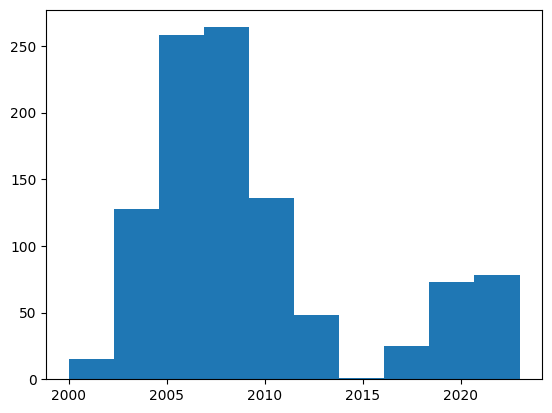

In [180]:
import matplotlib.pyplot as plt

plt.hist(df_merged["yod"])
plt.show()

In [181]:
# 3 Add mortality from wave 10 main file too  
df_d

,idauniq,r10iwstat,r1iwstat,r2iwstat,r3iwstat,r4iwstat,r5iwstat,r6iwstat,r7iwstat,r8iwstat,r9iwstat,first_dead
0,100001,"9.nr, dk if alive or died",0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","4.nr, alive","1.resp, alive","9.nr, dk if alive or died","9.nr, dk if alive or died",NaN
1,100005,"9.nr, dk if alive or died",0.inap.,0.inap.,0.inap.,0.inap.,"1.resp, alive","4.nr, alive","4.nr, alive","4.nr, alive","1.resp, alive",NaN
2,100006,"9.nr, dk if alive or died",0.inap.,0.inap.,0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","9.nr, dk if alive or died","9.nr, dk if alive or died","9.nr, dk if alive or died",NaN
3,100007,"9.nr, dk if alive or died",0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive",NaN
4,100009,"9.nr, dk if alive or died",0.inap.,0.inap.,"1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","1.resp, alive","4.nr, alive","1.resp, alive",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
21674,947649,"1.resp, alive",0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,NaN
21675,947652,"1.resp, alive",0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,NaN
21676,947661,"1.resp, alive",0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,NaN
21677,947665,"1.resp, alive",0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,0.inap.,NaN


In [182]:
df_merged.columns


Index(['Unnamed: 0', 'idauniq', 'yob', 'yod', 'sex', 'eth', 'edu', 'wealth',
       'date1', 'date2',
       ...
       'fallinj_wave2', 'fallinj_wave3', 'fallinj_wave4', 'fallinj_wave5',
       'fallinj_wave6', 'fallinj_wave7', 'fallinj_wave8', 'fallinj_wave9',
       'eidatey', 'eirage'],
      dtype='object', length=101)

In [183]:
df_merged.date9

0        2018.971
1        2019.080
2        2018.971
3        2019.000
4        2018.750
           ...   
19797    2019.500
19798    2019.250
19799    2019.170
19800    2019.250
19801    2019.250
Name: date9, Length: 19802, dtype: float64

In [185]:
df_d.r5iwstat.value_counts()

r5iwstat
1.resp, alive                10274
0.inap.                       4919
9.nr, dk if alive or died     3405
6.nr, died prev wv            1626
4.nr, alive                    839
5.nr, died this wv             608
7.nr, dropped from samp          8
Name: count, dtype: int64

In [193]:
def get_first_dead_wave(row):
    for i, col in enumerate(iwstat_cols, 1):
        if row[col] == "5.nr, died this wv":
            return i
    return None

def get_2_dead_wave(row):
    for i, col in enumerate(iwstat_cols, 1):
        if row[col] == "6.nr, died prev wv":
            return i-1
    return None

df_d['wave_dead'] = df_d.apply(get_first_dead_wave, axis=1)

df_d['when_dead2'] = df_d.apply(get_2_dead_wave, axis=1)

In [194]:
df_d['wave_dead'].value_counts()

wave_dead
5.0    608
4.0    589
3.0    529
6.0    518
2.0    508
Name: count, dtype: int64

In [195]:
df_merged = df_merged.merge(df_d[['idauniq', 'wave_dead']], on='idauniq', how='left')

In [242]:
df_merged.loc[np.isnan(df_merged.wave_dead)==False, ["idauniq","yod","yob", "wave_dead","wave_dead_yod", "died"]].iloc[1:40,:]

,idauniq,yod,yob,wave_dead,wave_dead_yod,died
49,100067,2005.000,1930.0,3.0,2005.795,75.000
56,100074,2009.907,1930.0,5.0,2009.907,79.907
65,100083,2009.907,1941.0,5.0,2009.907,68.907
100,101534,2011.819,1952.0,6.0,2011.819,59.819
114,101784,2005.795,1942.0,3.0,2005.795,63.795
117,101896,2005.795,1944.0,3.0,2005.795,61.795
118,101955,2011.819,1948.0,6.0,2011.819,63.819
137,102626,2005.000,1926.0,3.0,2005.795,79.000
169,103517,2007.884,1945.0,4.0,2007.884,62.884
173,103713,2011.819,1931.0,6.0,2011.819,80.819


In [212]:
df_merged.loc[df_merged.idauniq == 101784, ].iloc[:, 1:20]

,idauniq,yob,yod,sex,eth,edu,wealth,date1,date2,date3,date4,date5,date6,date7,date8,date9,empl,angina,heartattack
114,101784,1942.0,NaN,1,1.0,NaN,4.0,2002.663,2004.83,2006.795,2008.884,2010.907,2012.819,2014.84,2016.87,2018.971,0.0,NaN,NaN


In [ ]:
# the column wave_dead_yod has the value of the dateN where N is the wave number from wave_dead 
df_merged["wave_dead_yod"] = df_merged.apply(
    lambda row: row[f"date{int(row.wave_dead)}"] if not np.isnan(row.wave_dead) else np.nan,
    axis=1
)

In [214]:
# make this 1 year before:
# lets assume the event was 1 before the question was asked (in the middle of this wave)
df_merged.loc[~df_merged['wave_dead_yod'].isna(), 'wave_dead_yod'] = df_merged.loc[~df_merged['wave_dead_yod'].isna(), 'wave_dead_yod'] - 1

In [ ]:
# if there is no "yod", we populate it from wave_dead_yod
df_merged.loc[df_merged['yod'].isna(), 'yod'] = df_merged.loc[df_merged['yod'].isna(), 'wave_dead_yod']

In [ ]:
# known mortality events
sum(~np.isnan(df_merged.yod)) #2930

2930

In [241]:
# died - age at death, also populate from wave_dead_yod - yob
df_merged.loc[df_merged['died'].isna(), 'died'] = df_merged.loc[df_merged['died'].isna(), 'wave_dead_yod'] - df_merged.loc[df_merged['died'].isna(), 'yob'] 

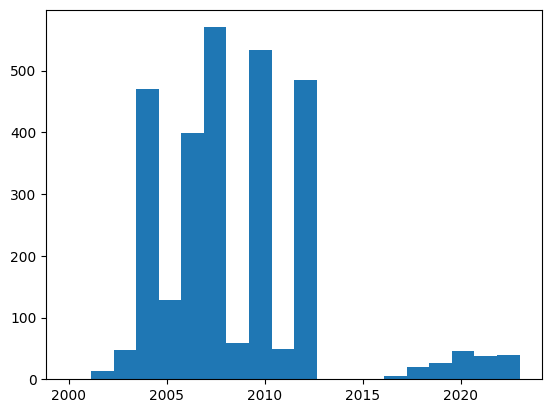

In [246]:
plt.hist(df_merged["yod"],bins = 20)
plt.show()

In [236]:
df_merged.yod.describe()

count    2930.000000
mean     2008.576246
std         4.048817
min      2000.000000
25%      2005.795000
50%      2007.884000
75%      2010.000000
max      2023.000000
Name: yod, dtype: float64

In [234]:
sum(df3_short["eidatey"]== 2017)

5